---
# <center>Principal components analysis (PCA)</center>
---

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

# Import some data

In [4]:
#from sklearn.datasets import load_boston

# X, _ = load_boston(return_X_y=True)
# X = pd.DataFrame(X)
df = pd.read_csv('/kaggle/input/boston-dataset/BostonHousing.csv')
df.columns = range(df.shape[1])
X=df
X

#PCA comprises 2 steps 
# Normalize the data 
#Xnorm = (X-μ)/(σ) 

# Perform Singular Value decomposition on the Normalized data . 
#Xnorm = UΣVt

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4,0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6,0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9,0
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0,0


## Scatter plot

<Axes: xlabel='6', ylabel='7'>

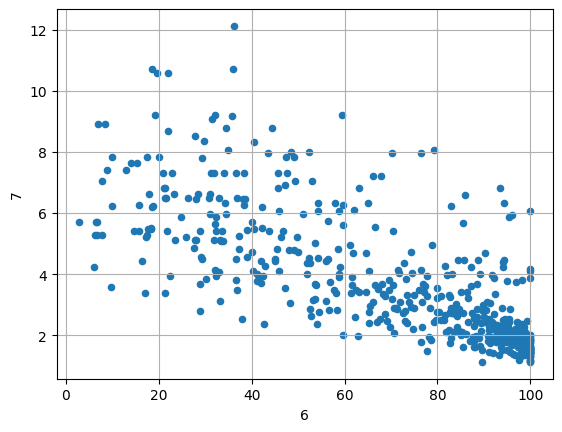

In [10]:
#X.plot(kind='scatter',x=6,y=7, grid=True)
#sns.scatterplot(data=X , x = 6, y =7)
X.plot(kind='scatter', x = 6, y=7, grid=True )

# Step 1: Normalize the data

Centering the data so that the mean of each feature (column) is 0 [1]. This practice is common in machine learning and data analysis to ensure that all features contribute equally to the results, regardless of their original scales. 

<img src="Xnorm.png" alt="Drawing" style="width: 200px;"/>

In [15]:
X.describe()
# the mean for all of the columns together form the mean (μ) in a 13 dimensional space. 
# std is the standard deviation . Compare the std dev between columns 6 and 7 , the vast scale difference can have a poor impact on the 
# nuumerical computation of SVD . Hence , we need to make the std dev as 1 for all 13 , by shifting the data cloud to its origin (mean close to 0) by normalizing the data . 

# Xnorm = (X-mu) /sigma 

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806,0.166008
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104,0.372456
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000,0.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000,0.000000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000,0.000000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000,0.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000,1.000000


In [23]:
mu = X.mean()
sigma = X.std()
#sigma
#mu

0       8.601545
1      23.322453
2       6.860353
3       0.253994
4       0.115878
5       0.702617
6      28.148861
7       2.105710
8       8.707259
9     168.537116
10      2.164946
11      7.141062
12      9.197104
13      0.372456
dtype: float64

In [34]:
#Normalize the data 
Xnorm = (X-mu)/sigma 
Xnorm.describe().loc['std']
Xnorm.describe().loc['mean']


0    -1.123388e-16
1     6.319056e-17
2     2.527622e-16
3    -9.829643e-17
4    -1.404235e-16
5    -9.829643e-17
6    -1.685082e-16
7    -1.123388e-16
8     1.123388e-16
9     5.616939e-17
10   -3.370163e-16
11   -3.229740e-16
12   -5.336092e-16
13   -4.212704e-17
Name: mean, dtype: float64

In [19]:
Xnorm.std()

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
dtype: float64

<AxesSubplot:xlabel='6', ylabel='7'>

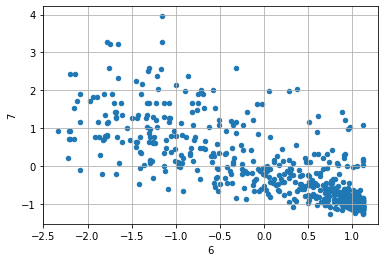

In [5]:
Xnorm.plot(kind='scatter', x=6, y=7, grid=True)

# Step 2: Perform SVD on the normalized data

<img src="svd.png" alt="Drawing" style="width: 200px;"/>

In [36]:
from scipy.linalg  import svd 
# Xnorm =   U s Vt 
U, s, V = svd(Xnorm,full_matrices=False)  # set full_matrices to False , otherwise will get matrices padded with 0 .
Sigma = np.diag(s) ## this is necessary because the svd lib returns s in a way that we need to construct a diagonal matrix. 
Vt = V.T

## We can check the decomposition

In [42]:
np.allclose(Xnorm, U@Sigma@Vt)  # @ is matrix multiplication , compare to Xnorm using numpy allclose method for matrix  . 

True

## We can recover the original dataset from the decomposition

<img src="unXnorm.png" alt="Drawing" style="width: 200px;"/>

In [50]:
Xrecov=mu  + (sigma*Xnorm )
Xrecoverd = mu + sigma * pd.DataFrame(U@Sigma@Vt)

print(np.allclose(X, Xrecoverd))
print(np.allclose(X, Xrecov))

True
True
